In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import zipfile

zip_path = "/content/archive.zip"   # replace with actual name
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os
print(os.listdir("/content"))

['.config', 'archive.zip', 'dataset', 'sample_data']


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

import matplotlib.pyplot as plt
import numpy as np
import os

In [7]:
import os

dataset_path = "/content/dataset"

print(os.listdir(dataset_path)[:10])

['PlantVillage', 'plantvillage']


In [8]:
import os

print("PlantVillage:")
print(os.listdir("/content/dataset/PlantVillage")[:10])

print("\nplantvillage:")
print(os.listdir("/content/dataset/plantvillage")[:10])

PlantVillage:
['Potato___healthy', 'Tomato__Target_Spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Potato___Early_blight', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Early_blight']

plantvillage:
['PlantVillage']


In [14]:
dataset_path = "/content/dataset/PlantVillage"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [15]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print(class_names[:10])

Number of classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [11]:
import os

print(os.listdir("/content/dataset"))

['PlantVillage', 'plantvillage']


In [12]:
print(os.listdir("/content/dataset/plantvillage"))

['PlantVillage']


In [13]:
print(os.listdir("/content/dataset/PlantVillage")[:10])

['Potato___healthy', 'Tomato__Target_Spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Potato___Early_blight', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Early_blight']


In [16]:
import os

classes = sorted(os.listdir("/content/dataset/PlantVillage"))

print("Total folders:", len(classes))

for c in classes:
    print(c)

Total folders: 15
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [17]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(len(class_names), activation="softmax")
])

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_plant_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [22]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 73s 103ms/step - accuracy: 0.5955 - loss: 1.2527 - val_accuracy: 0.7087 - val_loss: 0.8559
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.7257 - loss: 0.8240 - val_accuracy: 0.7429 - val_loss: 0.7578
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.7606 - loss: 0.7167 - val_accuracy: 0.7730 - val_loss: 0.6531
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7869 - loss: 0.6379 - val_accuracy: 0.7805 - val_loss: 0.6154
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.7983 - loss: 0.5942 - val_accuracy: 0.7965 - val_loss: 0.5784
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.8140 - loss: 0.5429 - val_accuracy: 0.8144 - val_loss: 0.5349
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.8254 - loss: 0.5175 - val_accuracy: 0.8066 - val_loss: 0.5447
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.8323 - loss: 0.4906 -

In [23]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8231 - loss: 0.5314
Validation Accuracy: 82.31%
Validation Loss: 0.5314


In [24]:
model.save("plant_disease_model.keras")

In [25]:
base_model.trainable = True

In [26]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [27]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 59s 80ms/step - accuracy: 0.4790 - loss: 5.2834 - val_accuracy: 0.4175 - val_loss: 3.0339
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.6655 - loss: 1.0941 - val_accuracy: 0.6230 - val_loss: 1.3386
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.7408 - loss: 0.8017 - val_accuracy: 0.7306 - val_loss: 0.8816


In [29]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4175 - loss: 3.0339
Validation Accuracy: 41.75%
Validation Loss: 3.0339


In [30]:
import tensorflow as tf

model = tf.keras.models.load_model("best_plant_model.keras")

In [31]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.8231 - loss: 0.5314
Validation Accuracy: 82.31%
Validation Loss: 0.5314


In [32]:
model.save("plant_disease_model.keras")

In [33]:
import os

print(os.path.getsize("plant_disease_model.keras")/(1024*1024))

12.968729972839355


In [34]:
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [35]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [36]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

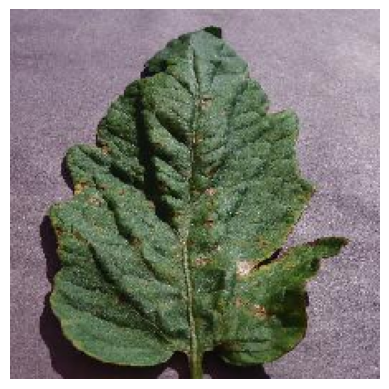

In [38]:
sample_path = "/content/dataset/PlantVillage/Tomato__Target_Spot/1dbc3729-aa02-46fb-9276-79a382f62026___Com.G_TgS_FL 7951.JPG"

img = image.load_img(sample_path, target_size=(224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

In [39]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]

print(f"The predicted class for the sample image is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
The predicted class for the sample image is: Tomato_healthy


In [40]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_disease(img_path):

    img = image.load_img(img_path, target_size=(224,224))

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

    plt.imshow(img)
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction: Tomato_Late_blight
Confidence: 100.00%


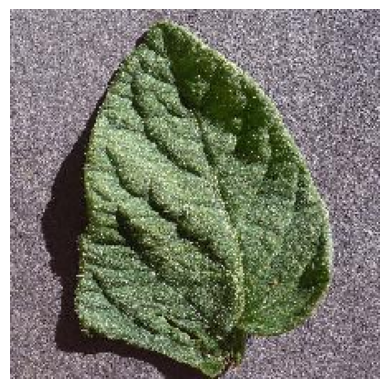

In [42]:
import random
import os

folder = "/content/dataset/PlantVillage/Tomato_healthy"

random_image = random.choice(os.listdir(folder))

img_path = os.path.join(folder, random_image)

predict_disease(img_path)

In [43]:
model.save("plant_disease_model.keras")

In [44]:
from google.colab import files

files.download("plant_disease_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [46]:
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction: Tomato_Late_blight
Confidence: 53.18%


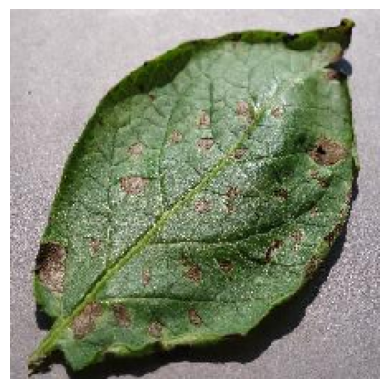

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: Tomato_Late_blight
Confidence: 100.00%


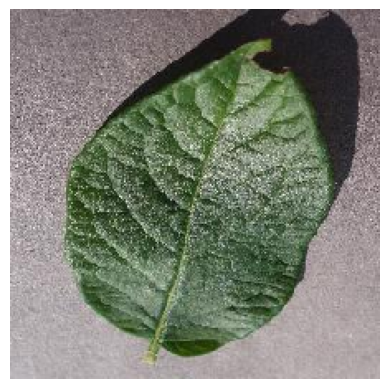

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: Tomato_Late_blight
Confidence: 100.00%


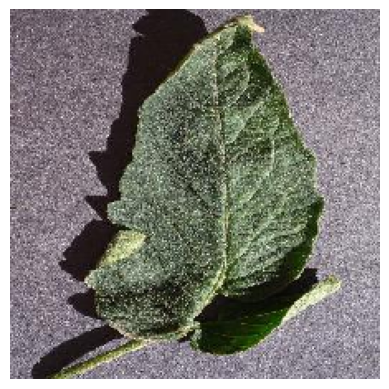

In [48]:
import random

def get_random_image_path(class_name):
    folder_path = os.path.join("/content/dataset/PlantVillage", class_name)
    if os.path.exists(folder_path) and os.listdir(folder_path):
        random_image = random.choice(os.listdir(folder_path))
        return os.path.join(folder_path, random_image)
    else:
        print(f"Warning: No images found in {folder_path}. Skipping.")
        return None

# Predict for Potato___Early_blight
img_path_early_blight = get_random_image_path("Potato___Early_blight")
if img_path_early_blight:
    predict_disease(img_path_early_blight)

# Predict for Potato___healthy
img_path_potato_healthy = get_random_image_path("Potato___healthy")
if img_path_potato_healthy:
    predict_disease(img_path_potato_healthy)

# Predict for Tomato___Late_blight
img_path_late_blight = get_random_image_path("Tomato___Late_blight")
if img_path_late_blight:
    predict_disease(img_path_late_blight)

# Predict for Tomato___healthy
img_path_tomato_healthy = get_random_image_path("Tomato_healthy") # Note: Corrected from Tomato___healthy to Tomato_healthy based on previous successful execution
if img_path_tomato_healthy:
    predict_disease(img_path_tomato_healthy)